<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Fundamentals_and_Applications/dz_topic_6_Bobrivets_Sofiia_AL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання до модуля «Алгоритми навчання з вчителем Ч.2»
## Rain in Australia — Logistic Regression

Мета: коректно підготувати дані та перевірити модель на останньому році спостережень, якого модель не бачила під час навчання.


## 1. Імпорт пакетів

In [3]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Завантаження Rain in Australia

In [4]:
!pip -q install kagglehub
import kagglehub

dataset_path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)

if not csv_files:
    raise FileNotFoundError("CSV-файл датасету не знайдено.")

weather_path = next((p for p in csv_files if "weatherAUS" in os.path.basename(p)), csv_files[0])
df = pd.read_csv(weather_path)

print("Dataset:", weather_path)
print("Shape:", df.shape)
display(df.head())
df.info()


Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
Dataset: /kaggle/input/weather-dataset-rattle-package/weatherAUS.csv
Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

## 3. Видалення ознак з великою кількістю пропусків і часові ознаки

In [5]:
missing_share = df.isna().mean().sort_values(ascending=False)
display(missing_share.head(10).to_frame("missing_share"))

high_missing_cols = missing_share[missing_share > 0.35].index.tolist()
print("Видаляємо:", high_missing_cols)
df = df.drop(columns=high_missing_cols).copy()

df = df.dropna(subset=["RainTomorrow"]).copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"]).copy()

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month.astype(str)

print("Роки:", sorted(df["Year"].unique()))
print("Останній рік:", df["Year"].max())


,missing_share
Sunshine,0.480098
Evaporation,0.431665
Cloud3pm,0.408071
Cloud9am,0.384216
Pressure9am,0.103568
Pressure3pm,0.103314
WindDir9am,0.072639
WindGustDir,0.070989
WindGustSpeed,0.070555
Humidity3pm,0.030984


Видаляємо: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
Роки: [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Останній рік: 2017


## 4. Числові та категоріальні ознаки

In [6]:
X = df.drop(columns=["RainTomorrow", "Date"]).copy()
y = df["RainTomorrow"].map({"No": 0, "Yes": 1})

valid = y.notna()
X = X.loc[valid].copy()
y = y.loc[valid].astype(int)

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

assert "Year" in numeric_cols
assert "Month" in categorical_cols

print("Числові:", numeric_cols)
print("\nКатегоріальні:", categorical_cols)


Числові: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year']

Категоріальні: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Month']


## 5. Історичний train/test split
До test відносимо всі записи максимального року, до train — всі попередні.


In [7]:
max_year = X["Year"].max()

train_mask = X["Year"] < max_year
test_mask = X["Year"] == max_year

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Test year:", max_year)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train years:", X_train["Year"].min(), "-", X_train["Year"].max())
print("Test years:", X_test["Year"].unique())

assert X_train["Year"].max() < X_test["Year"].min()


Test year: 2017
Train: (133727, 19) Test: (8466, 19)
Train years: 2007 - 2016
Test years: [2017]


## 6. Відновлення пропусків

In [8]:
X_train_num = X_train[numeric_cols]
X_test_num = X_test[numeric_cols]
X_train_cat = X_train[categorical_cols]
X_test_cat = X_test[categorical_cols]

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num_imp = num_imputer.fit_transform(X_train_num)
X_test_num_imp = num_imputer.transform(X_test_num)
X_train_cat_imp = cat_imputer.fit_transform(X_train_cat)
X_test_cat_imp = cat_imputer.transform(X_test_cat)

print("Imputation completed.")


Imputation completed.


## 7. StandardScaler

In [9]:
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num_imp)
X_test_num_scaled = scaler.transform(X_test_num_imp)

print(X_train_num_scaled.shape, X_test_num_scaled.shape)


(133727, 13) (8466, 13)


## 8. OneHotEncoder

In [10]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_cat_imp)
X_test_cat_encoded = encoder.transform(X_test_cat_imp)

print(X_train_cat_encoded.shape, X_test_cat_encoded.shape)


(133727, 111) (8466, 111)


## 9. Об'єднання ознак

In [11]:
X_train_ready = np.hstack([X_train_num_scaled, X_train_cat_encoded])
X_test_ready = np.hstack([X_test_num_scaled, X_test_cat_encoded])

print("Final train:", X_train_ready.shape)
print("Final test:", X_test_ready.shape)
assert X_train_ready.shape[1] == X_test_ready.shape[1]


Final train: (133727, 124)
Final test: (8466, 124)


## 10. Logistic Regression — експеримент із solver

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

solvers = ["lbfgs", "liblinear", "saga"]

results = []
models = {}

for solver in solvers:
    model = LogisticRegression(
        solver=solver,
        max_iter=2000,
        random_state=42
    )

    model.fit(X_train_ready, y_train)

    pred = model.predict(X_test_ready)

    results.append({
        "solver": solver,
        "accuracy": accuracy_score(y_test, pred)
    })

    models[solver] = model

results_df = pd.DataFrame(results).sort_values(
    "accuracy",
    ascending=False
)

display(results_df)


,solver,accuracy
0,lbfgs,0.847153
2,saga,0.847153
1,liblinear,0.847035


## 11. Classification report і confusion matrix

Solver: lbfgs
              precision    recall  f1-score   support

     No rain       0.87      0.95      0.91      6703
        Rain       0.71      0.44      0.55      1763

    accuracy                           0.85      8466
   macro avg       0.79      0.70      0.73      8466
weighted avg       0.84      0.85      0.83      8466



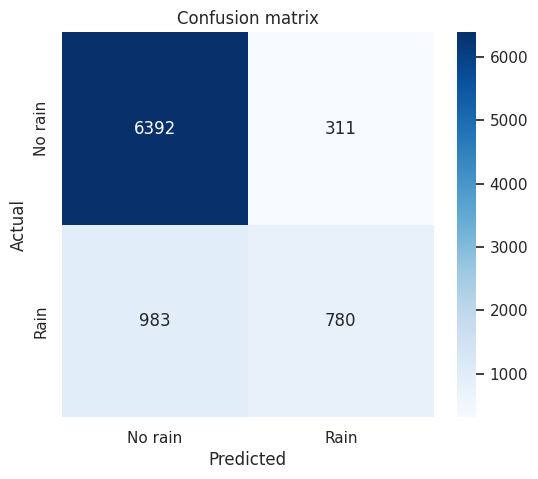

In [13]:
best_solver = results_df.iloc[0]["solver"]
model = models[best_solver]
y_pred = model.predict(X_test_ready)

print("Solver:", best_solver)
print(classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["No rain", "Rain"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No rain", "Rain"],
            yticklabels=["No rain", "Rain"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()


## 12. Висновки

У роботі використано історичне розділення даних: модель навчається на всіх роках, крім останнього, а тестується на останньому році. Такий підхід краще моделює реальне прогнозування майбутнього, ніж випадкове перемішування спостережень різних років.

Ознаки з великою часткою пропущених значень було видалено. Для інших пропусків застосовано `SimpleImputer`. Числові ознаки нормалізовано за допомогою `StandardScaler`, а категоріальні закодовано через `OneHotEncoder`. `Year` використано як числову ознаку, а `Month` — як категоріальну.

Для `LogisticRegression` проведено експеримент із кількома значеннями `solver`. Якість фінальної моделі оцінюється за `classification_report` і матрицею помилок. Під час інтерпретації важливо аналізувати не лише accuracy, а також precision, recall і F1-score для класу `Rain`, оскільки класи в наборі даних незбалансовані.

Метрики можуть відрізнятися від базової моделі з конспекту, оскільки тут тестова вибірка складається лише з умовного «майбутнього». Саме це дає реалістичнішу оцінку здатності моделі узагальнювати на новий часовий період.



Обраний підхід: **намагатися отримати вищий бал шляхом можливого подальшого доопрацювання роботи відповідно до фідбеку ментора**.
